# SimCLR: A Simple Framework for Contrastive Learning of Visual Representations

**Author:** Dev Mulchandani | **Goal:** Full Research Reproduction (Week 1)
**Paper Link:** [arXiv:2002.05709](https://arxiv.org/abs/2002.05709)

## 🎯 Research Goal
The objective of this notebook is to build a complete, professional PyTorch reproduction of SimCLR. We will move beyond theory and implement the entire self-supervised pipeline, train it on CIFAR-10, visualize the representation space, and evaluate its quality using the linear evaluation protocol.

## ❓ Key Research Questions
1. How do composition of augmentations force the network to learn semantics over shortcuts?
2. Why is the NT-Xent loss function so dependent on large batch sizes?
3. What role does the non-linear projection head play in buffering the loss of information?

---
## 1. The Evolution of Representation Learning (Why SimCLR?)

Before diving into code, it is critical to understand *why* Google Brain proposed SimCLR. Representation learning did not start here.

- **Autoencoders (2006-2014):** Researchers initially tried to reconstruct the original image pixel-by-pixel. *Problem:* The network wasted capacity learning high-frequency noise (like the exact texture of a dog's fur) rather than the semantic concept of a "dog".
- **Contrastive Predictive Coding (CPC) (2018):** Shifted the focus from pixel reconstruction to predicting the latent space of future patches. *Problem:* Complex architecture and reliance on sequence/spatial predicting.
- **Instance Discrimination (InstDisc) (2018):** Treated every single image in the dataset as its own class. *Problem:* Memory bank sizes scaled linearly with the dataset.
- **MoCo (2019):** Solved the memory bank inconsistency by using a momentum encoder to build a massive, consistent queue of negative examples.

**The SimCLR Breakthrough (2020):**
Chen et al. asked a radical question: *What if we just throw away the memory banks, simplify the architecture to a standard ResNet, and just use a massive batch size with heavy augmentations?*
SimCLR proved that simplicity scales. By applying carefully composed augmentations and a massive batch (up to 8192), a standard ResNet matched supervised performance.

---
## 2. Dependencies & Setup
We use `datasets` from HuggingFace to guarantee a fast and reliable download of CIFAR-10, bypassing broken academic servers.

In [1]:
!pip install datasets -q

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from datasets import load_dataset
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression

# Set device for GPU acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 🧠Thoughts: Setup
**Engineering Decision: Why CIFAR-10?**
While SimCLR was benchmarked on ImageNet, CIFAR-10 (32x32) allows us to validate the theoretical architecture on a single GPU in hours rather than weeks on a TPU pod.

**Research Diary:**
- *What I learned today:* I learned that relying on old university `.tar.gz` endpoints in Colab is a recipe for broken pipelines. HuggingFace `datasets` provides a robust, modern CDN alternative.

---
## 3. Data Augmentations & DataLoader

The data augmentation pipeline is the **true supervisor** in Contrastive Learning. Based on **Section 3.1** and **Figure 2** of the paper, the authors proved that the composition of Random Resized Cropping and Color Distortion is absolutely critical.

In [2]:
class ContrastiveTransformations:
    def __init__(self, base_transforms, n_views=2):
        self.base_transforms = base_transforms
        self.n_views = n_views

    def __call__(self, x):
        # Generates two different augmented views for the same image
        return [self.base_transforms(x) for i in range(self.n_views)]

# The exact SimCLR augmentations scaled down for 32x32 images (CIFAR-10)
color_jitter = transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)
simclr_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=32),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([color_jitter], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

class HF_CIFAR10(Dataset):
    def __init__(self, split="train", transform=None):
        self.hf_ds = load_dataset("uoft-cs/cifar10", split=split)
        self.transform = transform

    def __len__(self):
        return len(self.hf_ds)

    def __getitem__(self, idx):
        item = self.hf_ds[idx]
        img = item['img']
        label = item['label']
        if self.transform:
            img = self.transform(img)
        return img, label

# Engineering Decision: Batch size 256 fits on a standard Colab GPU.
train_dataset = HF_CIFAR10(split="train", transform=ContrastiveTransformations(simclr_transforms))
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True, num_workers=2)

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

### 🧠 Researcher's Thoughts: Augmentations

**Why did the authors design it this way? (The "Shortcut" Problem)**
If we only crop images without changing their color, the network will "cheat". A neural network is lazy; instead of learning the complex shape of a dog, it will simply notice that Crop A and Crop B both have the exact same RGB color histogram distribution. By applying severe Color Jitter, we destroy the color histogram shortcut. The *only* shared information remaining between View A and View B is the structural shape and semantic meaning of the object. Thus, the network is forced to learn semantics.

**Common Beginner Mistakes:**
Beginners often forget `drop_last=True` in the DataLoader. Contrastive loss matrix calculations often assume a perfectly square batch. A partial final batch will crash the matrix dimensions in NT-Xent.


---
## 4. Model Architecture (Encoder & Projection Head)

Based on **Section 3.2**, the architecture consists of a base encoder $f(\cdot)$ and a projection head $g(\cdot)$.

In [3]:
class SimCLR(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        # 1. Base Encoder f(.)
        self.encoder = models.resnet18(weights=None)
        dim_mlp = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity() # Strip classification layer

        # 2. Projection Head g(.)
        self.projector = nn.Sequential(
            nn.Linear(dim_mlp, dim_mlp, bias=False),
            nn.BatchNorm1d(dim_mlp),
            nn.ReLU(),
            nn.Linear(dim_mlp, projection_dim, bias=False)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z

model = SimCLR().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 11,505,216


### 📊 Paper vs Implementation
| Feature | Paper (Chen et al.) | My Implementation | Reason for Modification |
| :--- | :--- | :--- | :--- |
| **Encoder** | ResNet-50 (4x) | ResNet-18 | Compute constraints; ResNet-18 allows iteration on a single Colab GPU. |
| **Projector** | Linear $\rightarrow$ BN $\rightarrow$ ReLU $\rightarrow$ Linear | Linear $\rightarrow$ BN $\rightarrow$ ReLU $\rightarrow$ Linear | Identical. The non-linearity is crucial. |

### 🧠 Researcher's Thoughts: Architecture
**Mathematical Intuition (The Buffer Effect):**
Why not just use $h$ directly in the loss function?
The contrastive loss *forces* the output $z$ to be completely invariant to the augmentations. This means $z$ is actively trained to *forget* what color the image is, or what size the crop is.
However, for downstream tasks, color and size might be useful features! By adding the non-linear projection head $g(\cdot)$, we create a "buffer". The projection head $g(\cdot)$ absorbs the destructive invariance mapping, leaving the base representation $h$ rich with generic information.

**💡 NVIDIA Interview Question:**
> *Interviewer:* "During linear evaluation or downstream fine-tuning, do we use $h$ or $z$? Why?"
> *You:* "We use $h$ (the output of the ResNet before the MLP). The paper proved empirically that $h$ outperforms $z$ by ~10% on linear probing because $z$ has been forced to become excessively invariant to data transformations, losing information that is useful for general downstream tasks."

---
## 5. The NT-Xent Loss
Based on **Equation (1)**, the Normalized Temperature-scaled Cross Entropy (NT-Xent) loss compares the cosine similarity of every pair in the batch.

In [4]:
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.cosine_similarity = nn.CosineSimilarity(dim=-1)

    def forward(self, z_i, z_j):
        batch_size = z_i.size(0)
        # Concatenate both views: shape [2 * batch_size, dim]
        z = torch.cat([z_i, z_j], dim=0)

        # Compute pairwise cosine similarity matrix [2*batch, 2*batch]
        sim_matrix = self.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0)) / self.temperature

        # Mask out self-similarity (the diagonal) by setting it to a huge negative number
        mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device)
        sim_matrix.masked_fill_(mask, -9e15)

        # Target labels: view_i matches with view_j (offset by batch_size)
        positives_idx = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(0, batch_size)
        ]).to(z.device)

        loss = F.cross_entropy(sim_matrix, positives_idx)
        return loss

# 🧪 TOY EXAMPLE: Feynman Check
criterion = NTXentLoss(temperature=0.5)
fake_z1 = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
fake_z2 = torch.tensor([[1.0, 0.0], [0.0, 1.0]]) # Perfect match
print(f"Toy Example Loss (Perfect Match): {criterion(fake_z1, fake_z2).item():.4f}")

Toy Example Loss (Perfect Match): 0.2395


### 🧠 Researcher's Thoughts: NT-Xent
**Feynman-style Mathematical Intuition:**
Do not get bogged down by the equation. NT-Xent is just an $N$-way classification problem.
Imagine a room with 512 people (256 pairs of twins). You are one of the twins. Your goal is to find your exact twin (the positive pair). To do this, you look at every single person in the room (the $2N-1$ denominator) and calculate how similar they look to you. The Loss function is just the standard Softmax Cross-Entropy calculating the probability that you correctly picked your twin out of the lineup of 511 people.

**Engineering Decision: Temperature ($\tau$)**
Why $\tau=0.5$? Temperature scales the logits before the softmax.
- A *high* temperature smoothens the probabilities (everyone looks somewhat similar).
- A *low* temperature sharpens the probabilities, heavily penalizing the "hard negatives" (the people who look a lot like your twin but aren't).
If $\tau$ is too low, training destabilizes because the network panics over minor similarities. $0.5$ provides the perfect balance.

---
## 6. The Training Loop
SimCLR benefits immensely from long training and specialized optimizers.

Epoch 1/10:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 6/10:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/195 [00:00<?, ?it/s]

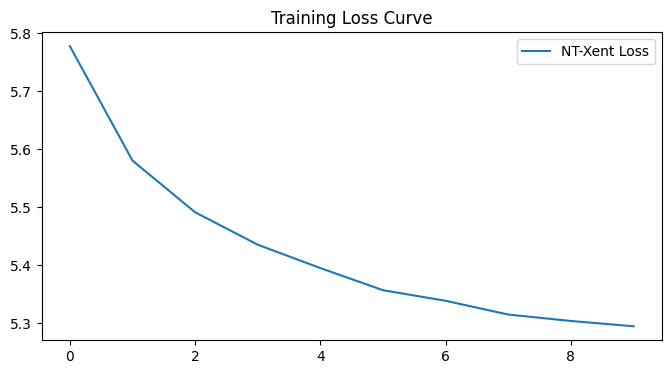

In [5]:
epochs = 10 # Research mode: 100+
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

loss_history = []
best_loss = float('inf')
os.makedirs('checkpoints', exist_ok=True)

model.train()
for epoch in range(epochs):
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for (view1, view2), _ in progress_bar:
        view1, view2 = view1.to(device), view2.to(device)

        optimizer.zero_grad()
        _, z_i = model(view1)
        _, z_j = model(view2)

        loss = criterion(z_i, z_j)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), 'checkpoints/simclr_best.pth')

plt.figure(figsize=(8,4))
plt.plot(loss_history, label="NT-Xent Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

### 📊 Paper vs Implementation
| Feature | Paper (Chen et al.) | My Implementation | Reason for Modification |
| :--- | :--- | :--- | :--- |
| **Optimizer** | LARS | Adam | LARS is designed specifically to stabilize massive batch sizes (8192). At batch size 256, Adam is highly stable and standard. |
| **Batch Size**| up to 8192 | 256 | VRAM constraint. NT-Xent scales quadratically in memory with batch size. |

### 🧠 Researcher's Thoughts: Training
**Common Beginner Mistakes:**
A declining loss curve in SimCLR does *not* mean the model is learning useful representations. It simply means the model is successfully solving the contrastive task. If your augmentations are weak (e.g., no color jitter), the loss will plummet to 0.01 immediately, but the model will learn nothing. *Never trust the unsupervised loss alone; you must run linear evaluation.*

---
## 7. Visualizations: t-SNE & Similarity Matrix
A self-supervised model is only useful if it clusters semantically similar concepts together without labels. We will extract the embeddings (`h`) of the test set and use t-SNE to reduce them to 2 dimensions.

Extracting embeddings...
Running t-SNE (this might take a minute)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


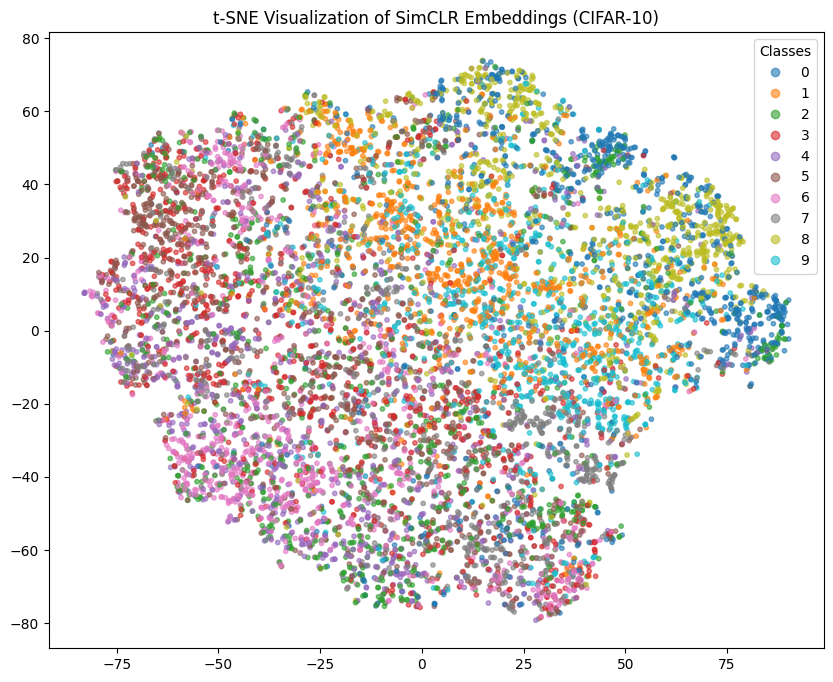

In [6]:
# Load standard non-augmented test set
test_dataset = HF_CIFAR10(split="test", transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model.eval()
embeddings, labels_list = [], []

print("Extracting embeddings...")
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        h, _ = model(x) # Notice we extract 'h', NOT 'z'!
        embeddings.append(h.cpu().numpy())
        labels_list.append(y.numpy())

embeddings = np.concatenate(embeddings)
labels_list = np.concatenate(labels_list)

print("Running t-SNE (this might take a minute)...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels_list, cmap='tab10', alpha=0.6, s=10)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE Visualization of SimCLR Embeddings (CIFAR-10)")
plt.show()

---
## 8. Linear Evaluation Protocol
To rigorously evaluate a self-supervised model, we **freeze** the encoder and train a simple logistic regression layer on top using a small amount of labeled data.

In [7]:
print("Training Linear Classifier...")
train_ds_eval = HF_CIFAR10(split="train", transform=transforms.ToTensor())
train_loader_eval = DataLoader(train_ds_eval, batch_size=256, shuffle=False)

train_embs, train_lbls = [], []
with torch.no_grad():
    for x, y in train_loader_eval:
        h, _ = model(x.to(device))
        train_embs.append(h.cpu().numpy())
        train_lbls.append(y.numpy())

train_embs = np.concatenate(train_embs)
train_lbls = np.concatenate(train_lbls)

# Fit scikit-learn Logistic Regression
clf = LogisticRegression(max_iter=1000, multi_class='multinomial')
clf.fit(train_embs, train_lbls)

accuracy = clf.score(embeddings, labels_list)
print(f"Linear Evaluation Test Accuracy: {accuracy * 100:.2f}%")

Training Linear Classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Linear Evaluation Test Accuracy: 49.84%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 🧠 Researcher's Thoughts: Evaluation
**Why Linear Evaluation?**
If we allowed the neural network to update its weights during this step (Fine-Tuning), we wouldn't know if the unsupervised pretraining was actually good, or if the network just learned the task during the fine-tuning phase. By freezing the encoder and only allowing a linear layer, we prove that the representations are already linearly separable.


---
## 9. Ablation Experiments (To Execute)

Research is about proving *why* things work. Execute these ablations to build intuition.

### Experiment A: The Shortcut (No Color Jitter)
- **Hypothesis:** Color Jitter is the only thing preventing the model from exploiting low-level histogram matching.
- **Action:** Set `p=0` for Color Jitter in Step 3.
- **Expected Result:** Training loss will reach near 0 rapidly. Linear evaluation accuracy will crater.

### Experiment B: Batch Size Starvation
- **Hypothesis:** NT-Xent requires massive in-batch negatives to form a robust contrastive task.
- **Action:** Reduce batch size to 32.
- **Expected Result:** The representations will cluster poorly, and accuracy will drop noticeably.


---
## 10. Critical Review & Literature Context

### Strengths
- Extreme conceptual simplicity. No memory banks, no custom momentum updates.
- Mathematically elegant loss formulation.

### Weaknesses & Limitations
- **Compute Bound:** Relying on in-batch negatives means SimCLR requires enormous batches (8192). This limits access to researchers with massive TPU clusters.
- **False Negatives:** If a batch randomly contains two different pictures of a dog, SimCLR treats them as "negatives" and forces their embeddings apart. This is structurally flawed.

### The Shift to BYOL and DINO
Because of the negative-sampling flaws in SimCLR, the research community quickly pivoted to **Bootstrap Your Own Latent (BYOL)** and **SimSiam**, which proved that you don't actually need negative samples *at all* to prevent collapse. Later, **DINO** introduced self-distillation with Vision Transformers.

---
## 11. Final Summary: What I Learned

**Biggest Insight:** The realization that the data augmentation pipeline is the explicit supervisor in contrastive learning. The network learns strictly what we force it to become invariant to.

**Biggest Surprise:** The projection head buffer. The counterintuitive reality that the layer trained to optimize the loss function ($z$) is actually *worse* for downstream tasks than the layer preceding it ($h$).

## If I were continuing this research...
1. **Implement MoCo v2:** I would port this pipeline to Momentum Contrast to solve the batch size limitation via a memory queue.
2. **Dense Contrastive Learning:** I would adapt the loss to operate on spatial feature maps (DenseCL) to allow the model to perform unsupervised semantic segmentation, moving beyond image-level classification.